In [153]:
# ML MODEL TRAINING AND IMPLEMENTATION

In [154]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [155]:
# System & paths
import sys
from pathlib import Path

In [156]:
# FOR MODELS - RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error, r2_score

In [157]:
# Project root (one level above notebooks/)
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [158]:
DATA_PATH = PROJECT_ROOT / "data" / "preprocessed" / "state_level_features.csv"

In [159]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

In [160]:
df = df.sort_values(['state_code', 'commodity', 'date']).reset_index(drop=True)

In [161]:
commodity = "rice"

df_c = df[df['commodity'] == commodity].copy()
df_c = df_c.sort_values(['state_code', 'date'])

In [162]:
# decide split date according to user
# here we are giving arbitrary
split_date = "2020-06-01"

In [163]:
train_df = df_c[df_c['date'] < split_date]
test_df  = df_c[df_c['date'] >= split_date]

In [164]:
feature_cols = [
    'lag_1', 'lag_2', 'lag_3',
    'lag_6', 'lag_9', 'lag_12',
    'rolling_mean_3', 'rolling_mean_6',
    'rolling_std_3'
]

target_col = 'total_allocated_qty'

In [165]:
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

In [166]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [167]:
# Predict for which state
state = "JH"

test_state = test_df[test_df['state_code'] == state].copy()

X_test = test_state[feature_cols]
y_test = test_state[target_col]

if test_state.empty:
    print(f"No test data available for {state} - {commodity}")
    y_pred=[]
else:
    y_pred = model.predict(X_test)

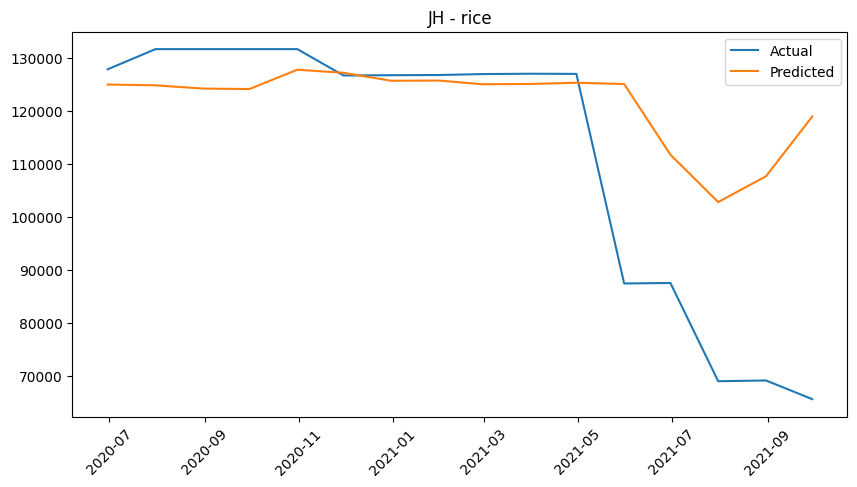

In [168]:
plt.figure(figsize=(10,5))

plt.plot(test_state['date'], y_test, label='Actual')
plt.plot(test_state['date'], y_pred, label='Predicted')

plt.title(f"{state} - {commodity}")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [169]:
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"MAPE  : {mape:,.2f}")
print(f"RMSE : {rmse:,.2f}")

MAPE  : 0.18
RMSE : 21,879.31


In [170]:
r2 = r2_score(y_test, y_pred)
print(f"R2 Score : {r2:,.2f}")

R2 Score : 0.25


In [171]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df

,feature,importance
2,lag_3,0.343694
7,rolling_mean_6,0.257177
0,lag_1,0.159412
6,rolling_mean_3,0.110143
1,lag_2,0.057030
3,lag_6,0.045350
4,lag_9,0.016487
5,lag_12,0.006027
8,rolling_std_3,0.004681
